# Lab 2 - Metoda najmniejszych kwadratów

In [ ]:

import numpy as np
import pandas as pd
import scipy.linalg
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# a
df = pd.read_csv("YearPredictionMSD.txt", header=None)

# b
df_train = df.iloc[:463715].copy()
df_test = df.iloc[463715:].copy()

print(f"Rozmiar zbioru treningowego: {df_train.shape[0]} wierszy.")
print(f"Rozmiar zbioru testowego: {df_test.shape[0]} wierszy.")

Rozmiar zbioru treningowego: 463715 wierszy.
Rozmiar zbioru testowego: 51630 wierszy.


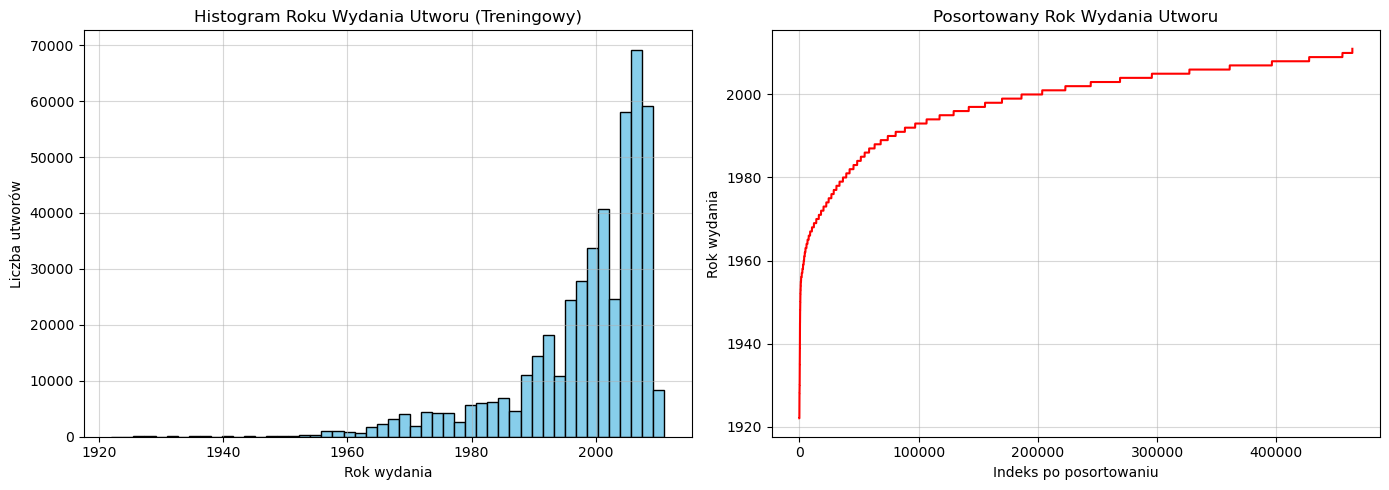

In [ ]:
# c
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df_train[0], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram Roku Wydania Utworu (Treningowy)')
plt.xlabel('Rok wydania')
plt.ylabel('Liczba utworów')
plt.grid(True, alpha=0.5)

plt.subplot(1, 2, 2)
sorted_years = np.sort(df_train[0].values)
plt.plot(sorted_years, color='red')
plt.title('Posortowany Rok Wydania Utworu')
plt.xlabel('Indeks po posortowaniu')
plt.ylabel('Rok wydania')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# d
y_train_raw = df_train[0].values
A_train_raw = df_train.drop(0, axis=1).values

y_test_raw = df_test[0].values
A_test_raw = df_test.drop(0, axis=1).values

A_train_raw = np.hstack((np.ones((A_train_raw.shape[0], 1)), A_train_raw))
A_test_raw = np.hstack((np.ones((A_test_raw.shape[0], 1)), A_test_raw))

features_train = df_train.drop(0, axis=1).values
features_test = df_test.drop(0, axis=1).values

f_min = features_train.min(axis=0)
f_max = features_train.max(axis=0)

f_range = f_max - f_min
f_range[f_range == 0] = 1.0 

features_train_scaled = (features_train - f_min) / f_range
features_test_scaled = (features_test - f_min) / f_range

y_min = y_train_raw.min()
y_max = y_train_raw.max()
y_train_scaled = (y_train_raw - y_min) / (y_max - y_min)
y_test_scaled = (y_test_raw - y_min) / (y_max - y_min)

A_train_scaled = np.hstack((np.ones((features_train_scaled.shape[0], 1)), features_train_scaled))
A_test_scaled = np.hstack((np.ones((features_test_scaled.shape[0], 1)), features_test_scaled))

In [ ]:
# e
ATA_raw = np.matmul(A_train_raw.T, A_train_raw)
ATy_raw = np.matmul(A_train_raw.T, y_train_raw)
w_raw = np.linalg.solve(ATA_raw, ATy_raw)

# f
w_svd = scipy.linalg.lstsq(A_train_raw, y_train_raw)[0]

# f
lam = 0.01
diag_lam = lam * np.eye(A_train_raw.shape[1])
diag_lam[0, 0] = 0
w_reg = np.linalg.solve(ATA_raw + diag_lam, ATy_raw)

# e
ATA_scaled = np.matmul(A_train_scaled.T, A_train_scaled)
ATy_scaled = np.matmul(A_train_scaled.T, y_train_scaled)
w_scaled = np.linalg.solve(ATA_scaled, ATy_scaled)

In [ ]:
# g
cond_raw = np.linalg.cond(ATA_raw)
cond_scaled = np.linalg.cond(ATA_scaled)

print(f"Uwarunkowanie macierzy (nieznormalizowanej): {cond_raw:.2e}")
print(f"Uwarunkowanie macierzy (znormalizowanej): {cond_scaled:.2e}")

Uwarunkowanie macierzy (nieznormalizowanej): 3.87e+09
Uwarunkowanie macierzy (znormalizowanej): 2.15e+06


In [ ]:
# h
pred_raw = np.matmul(A_test_raw, w_raw)
mae_raw = mean_absolute_error(y_test_raw, pred_raw)

pred_svd = np.matmul(A_test_raw, w_svd)
mae_svd = mean_absolute_error(y_test_raw, pred_svd)

pred_reg = np.matmul(A_test_raw, w_reg)
mae_reg = mean_absolute_error(y_test_raw, pred_reg)

pred_scaled_y = np.matmul(A_test_scaled, w_scaled)
pred_scaled_reversed = pred_scaled_y * (y_max - y_min) + y_min
mae_scaled = mean_absolute_error(y_test_raw, pred_scaled_reversed)

print(f"MAE (Rownanie Normalne, Nieznormalizowane): {mae_raw:.4f} lat")
print(f"MAE (Scipy lstsq/SVD, Nieznormalizowane): {mae_svd:.4f} lat")
print(f"MAE (Rownanie Normalne Regularyzowane, lambda=0.01): {mae_reg:.4f} lat")
print(f"MAE (Rownanie Normalne, Znormalizowane): {mae_scaled:.4f} lat")

MAE (Równanie Normalne, Nieznormalizowane): 6.8005 lat
MAE (Scipy lstsq/SVD, Nieznormalizowane): 6.8005 lat
MAE (Równanie Normalne Regularyzowane, lambda=0.01): 6.8005 lat
MAE (Równanie Normalne, Znormalizowane): 6.8005 lat


In [ ]:
# i

block_sizes = [100000, 100000, 100000, 100000, 63715]
start_idx = 0
P_inv = np.zeros((A_train_raw.shape[1], A_train_raw.shape[1]))
Q_vec = np.zeros(A_train_raw.shape[1])

print("Inkrementacyjne obliczanie wag (Filtr Kalmana):")
for i, b_size in enumerate(block_sizes):
    end_idx = start_idx + b_size
    A_block = A_train_raw[start_idx:end_idx]
    y_block = y_train_raw[start_idx:end_idx]

    P_inv += np.matmul(A_block.T, A_block)
    Q_vec += np.matmul(A_block.T, y_block)
    
    w_kalman = np.linalg.solve(P_inv, Q_vec)
    
    pred_kalman = np.matmul(A_test_raw, w_kalman)
    mae_kalman = mean_absolute_error(y_test_raw, pred_kalman)
    
    print(f"   Po przetworzeniu bloku A{i+1} (laczna liczba próbek: {end_idx}): MAE = {mae_kalman:.4f} lat")
    
    start_idx = end_idx

Inkrementacyjne obliczanie wag (Filtr Kalmana):
   Po przetworzeniu bloku A1 (łączna liczba próbek: 100000): MAE = 6.8461 lat
   Po przetworzeniu bloku A2 (łączna liczba próbek: 200000): MAE = 6.8065 lat
   Po przetworzeniu bloku A3 (łączna liczba próbek: 300000): MAE = 6.7998 lat
   Po przetworzeniu bloku A4 (łączna liczba próbek: 400000): MAE = 6.8011 lat
   Po przetworzeniu bloku A5 (łączna liczba próbek: 463715): MAE = 6.8005 lat
